In [1]:
# Mengimport library pandas untuk membaca dataset dan eksplorasi data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Memasukkan file dataset yang akan digunakan
from google.colab import files
uploaded = files.upload()

Saving Data_Kelulusan_(2).csv to Data_Kelulusan_(2).csv


In [3]:
# baca dataset csv menggunakan syntax pd.read_csv()
df = pd.read_csv('Data_Kelulusan_(2).csv')

In [4]:
# Menampilkan dataset dalam bentuk tabel dengan memanggil df
df

,IPK,SKS,Frekuensi Kehadiran,Jumlah MK Ulang,Keikutsertaan Organisasi,Kelulusan
0,2.75,141.0,79.0,3.0,0,1
1,3.90,148.0,91.0,0.0,1,1
2,3.46,141.0,84.0,3.0,1,1
3,3.20,113.0,56.0,2.0,0,0
4,2.31,139.0,65.0,0.0,1,0
...,...,...,...,...,...,...
103,2.99,120.0,78.0,0.0,0,0
104,2.99,120.0,78.0,NaN,0,0
105,2.99,120.0,78.0,0.0,0,0
106,2.99,NaN,78.0,0.0,0,0


# 2. Ringkasan Data

In [5]:
# Menampilkan ringkasan data untuk memahami struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   IPK                       108 non-null    float64
 1   SKS                       107 non-null    float64
 2   Frekuensi Kehadiran       107 non-null    float64
 3   Jumlah MK Ulang           107 non-null    float64
 4   Keikutsertaan Organisasi  108 non-null    int64  
 5   Kelulusan                 108 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 5.2 KB


In [6]:
df['Keikutsertaan Organisasi'] = df['Keikutsertaan Organisasi'].map(str)
df['Kelulusan'] = df['Kelulusan'].map(str)



# 3. Mengecek Missing Value


In [7]:
# Mengecek missing value
df.isna().sum()

,0
IPK,0
SKS,1
Frekuensi Kehadiran,1
Jumlah MK Ulang,1
Keikutsertaan Organisasi,0
Kelulusan,0


In [8]:
# cek statistical summary
df.describe()

,IPK,SKS,Frekuensi Kehadiran,Jumlah MK Ulang
count,108.000000,107.000000,107.000000,107.000000
mean,2.943889,129.700935,76.971963,1.439252
std,0.572337,12.236826,13.655780,1.125834
min,2.010000,110.000000,50.000000,0.000000
25%,2.400000,120.000000,67.500000,0.000000
50%,2.990000,131.000000,78.000000,1.000000
75%,3.437500,141.000000,86.000000,2.000000
max,3.970000,149.000000,98.000000,3.000000


In [9]:
# cek statistical summary pada variabel tertentu
df['Keikutsertaan Organisasi'].describe()

,Keikutsertaan Organisasi
count,108
unique,2
top,0
freq,54


In [10]:
# Mengatasi Missing Value
for column in df.columns:
  if df[column].dtypes == 'object':
    df[column].fillna(df[column].mode()[0], inplace=True)
  else:
    df[column].fillna(df[column].mean(), inplace=True)

/tmp/ipython-input-2720969494.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)
/tmp/ipython-input-2720969494.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [11]:
# cek kembali missing value
df.isna().sum()

,0
IPK,0
SKS,0
Frekuensi Kehadiran,0
Jumlah MK Ulang,0
Keikutsertaan Organisasi,0
Kelulusan,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   IPK                       108 non-null    float64
 1   SKS                       108 non-null    float64
 2   Frekuensi Kehadiran       108 non-null    float64
 3   Jumlah MK Ulang           108 non-null    float64
 4   Keikutsertaan Organisasi  108 non-null    object 
 5   Kelulusan                 108 non-null    object 
dtypes: float64(4), object(2)
memory usage: 5.2+ KB


# 4. Mengatasi Duplikat Data

In [13]:
# Mengecek apakh ad aduplikat di seluruh kolom
check_duplicate = df.duplicated().sum()
print(f"Jumlah data yang duplikat = {check_duplicate}")

Jumlah data yang duplikat = 5


In [14]:
# Handling Duplicate
df = df.drop_duplicates()

In [15]:
# Mengecek duplicate setelah di-handle
handle_duplicate = df.duplicated().sum()
print(f"Jumlah data yang duplikat = {handle_duplicate}")

Jumlah data yang duplikat = 0


In [16]:
print(handle_duplicate)

0


Visualisasi Data

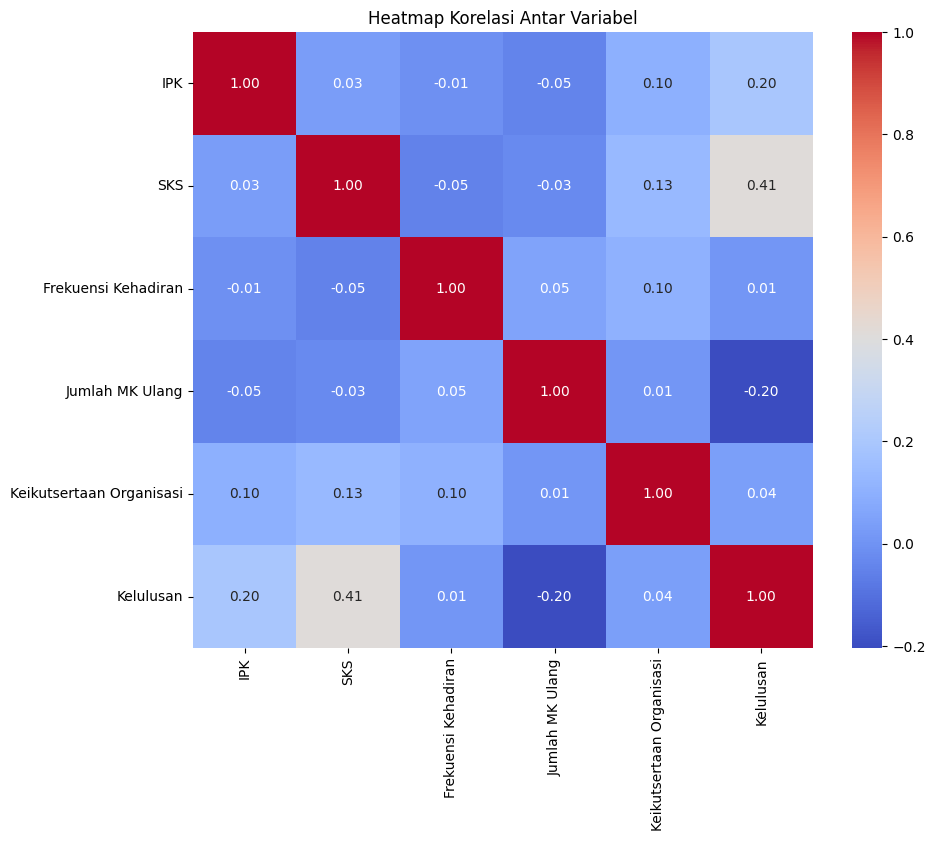

In [17]:
# Hitung Matriks Korelasi
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()